In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from scenarios.contracts import contract_cost_matrices
from scenarios.eligibility import eligible_contracts
from optimization.portfolio import scenario_npv, optimize_portfolio, efficient_frontier

In [2]:
zone = "nord"
archetype = "chemicals"
annual_kwh = 20_000_000
reference_zone = "sicilia"
has_market_access = False

eligible = eligible_contracts(zone, annual_kwh, has_wholesale_market_access=has_market_access, reference_zone=reference_zone)
matrices = contract_cost_matrices(zone, archetype, annual_kwh, reference_zone=reference_zone)

selected = {name: matrices[name] for name in sorted(eligible)}
selected["spot_only"] = matrices["spot_only"]

cost_npvs = {name: scenario_npv(m) for name, m in selected.items()}
summary = pd.DataFrame({name: npv.describe() for name, npv in cost_npvs.items()})
summary.drop("count") / 1e6

,baseload,sleeved,vppa,spot_only
mean,16.521814,17.368249,16.274912,18.368678
std,0.070244,0.482413,0.301280,0.566485
min,16.418619,16.624113,15.662579,17.536461
25%,16.435263,16.805124,15.983504,17.670687
50%,16.537390,17.475398,16.334680,18.494292
75%,16.591645,17.808528,16.529403,18.931831
max,16.613415,18.069651,16.852854,19.107402


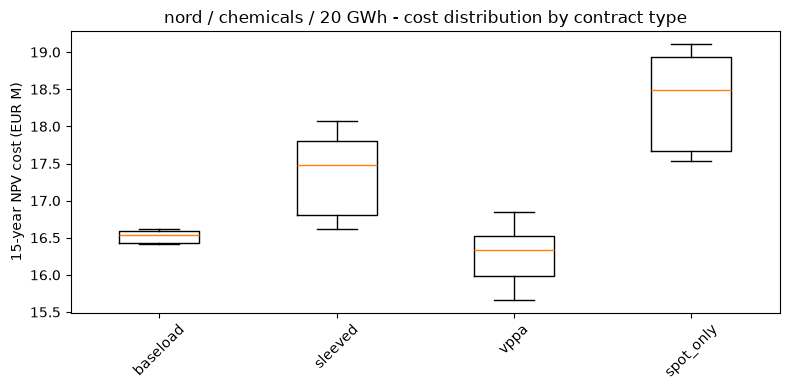

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([npv / 1e6 for npv in cost_npvs.values()], tick_labels=list(cost_npvs))
ax.set_ylabel("15-year NPV cost (EUR M)")
ax.set_title(f"{zone} / {archetype} / {annual_kwh / 1e6:.0f} GWh - cost distribution by contract type")
plt.xticks(rotation=45)
plt.tight_layout()

In [4]:
r = optimize_portfolio(cost_npvs, rho=8)
print("weights:", {k: round(v, 3) for k, v in r["weights"].items() if v > 1e-4})
pd.Series({
    "portfolio E[cost] (EUR M)": r["expected_cost"] / 1e6,
    "portfolio CVaR (EUR M)": r["cvar"] / 1e6,
    "do-nothing E[cost] (EUR M)": r["do_nothing_expected"] / 1e6,
    "do-nothing CVaR (EUR M)": r["do_nothing_cvar"] / 1e6,
    "expected saving (EUR M)": -r["expected_cost_change"] / 1e6,
    "CVaR reduction (EUR M)": r["cvar_reduction"] / 1e6,
}).round(2)

weights: {'baseload': 0.963, 'vppa': 0.037}


portfolio E[cost] (EUR M)     16.51
portfolio CVaR (EUR M)        16.61
do-nothing E[cost] (EUR M)    18.37
do-nothing CVaR (EUR M)       19.09
expected saving (EUR M)        1.86
CVaR reduction (EUR M)         2.48
dtype: float64

In [5]:
rhos = [0, 0.5, 1, 2, 3, 5, 8, 12, 20, 30]
frontier = efficient_frontier(cost_npvs, rhos)
frontier.round(3)

,baseload,sleeved,vppa,spot_only,expected_cost,cvar
rho,,,,,,
0.0,0.000,0.0,1.000,0.0,1.627491e+07,1.678676e+07
0.5,0.000,0.0,1.000,0.0,1.627491e+07,1.678676e+07
1.0,0.000,0.0,1.000,0.0,1.627491e+07,1.678676e+07
2.0,0.922,0.0,0.078,0.0,1.650263e+07,1.661101e+07
3.0,0.940,0.0,0.060,0.0,1.650705e+07,1.660947e+07
5.0,0.940,0.0,0.060,0.0,1.650705e+07,1.660947e+07
8.0,0.963,0.0,0.037,0.0,1.651276e+07,1.660864e+07
12.0,0.963,0.0,0.037,0.0,1.651276e+07,1.660864e+07
20.0,0.963,0.0,0.037,0.0,1.651276e+07,1.660864e+07


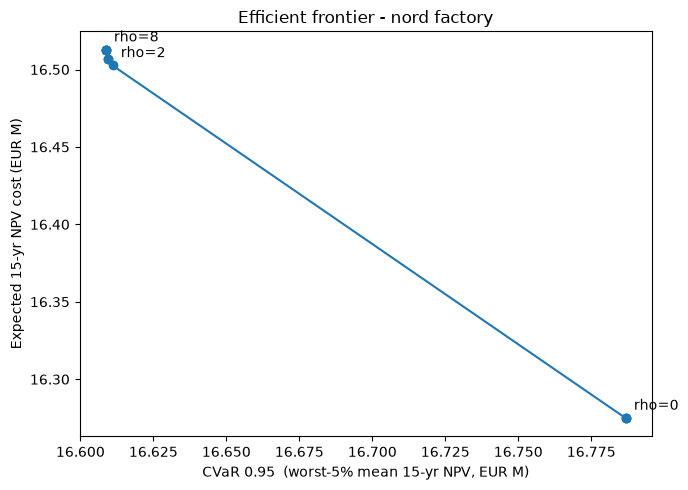

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(frontier["cvar"] / 1e6, frontier["expected_cost"] / 1e6, "o-")
for rho in [0, 2, 8]:
    row = frontier.loc[rho]
    ax.annotate(f"rho={rho}", (row["cvar"] / 1e6, row["expected_cost"] / 1e6), textcoords="offset points", xytext=(6, 6))
ax.set_xlabel("CVaR 0.95  (worst-5% mean 15-yr NPV, EUR M)")
ax.set_ylabel("Expected 15-yr NPV cost (EUR M)")
ax.set_title(f"Efficient frontier - {zone} factory")
plt.tight_layout()

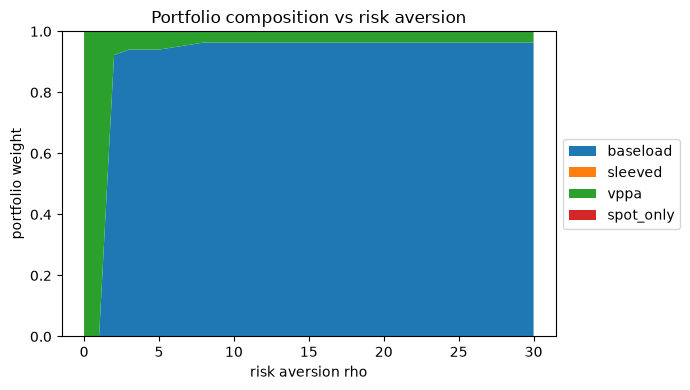

In [7]:
weight_cols = [c for c in frontier.columns if c not in ("expected_cost", "cvar")]
fig, ax = plt.subplots(figsize=(7, 4))
ax.stackplot(frontier.index, [frontier[c] for c in weight_cols], labels=weight_cols)
ax.set_xlabel("risk aversion rho")
ax.set_ylabel("portfolio weight")
ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Portfolio composition vs risk aversion")
plt.tight_layout()

In [8]:
zone2, ref2 = "sicilia", "sardegna"
elig2 = eligible_contracts(zone2, 50_000_000, has_wholesale_market_access=True, reference_zone=ref2)
mat2 = contract_cost_matrices(zone2, "chemicals", 50_000_000, reference_zone=ref2)

sel2 = {n: mat2[n] for n in sorted(elig2)}
sel2["spot_only"] = mat2["spot_only"]
npv2 = {n: scenario_npv(m) for n, m in sel2.items()}

efficient_frontier(npv2, [0, 5, 20]).round(3)

,baseload,pap_solar,pap_wind,vppa,spot_only,expected_cost,cvar
rho,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,4.407483e+07,4.512421e+07
5,1.0,0.0,0.0,0.0,0.0,4.407483e+07,4.512421e+07
20,1.0,0.0,0.0,0.0,0.0,4.407483e+07,4.512421e+07
